# TensorFlow content recommender (v1)

**CST4275 Master's Individual Thesis — Swetank Mohanty (M01087647)**
Supervisor: Dr Siddhaling Urolagin, Middlesex University Dubai

Upgrades the v0 baseline (`03_baseline_model.ipynb`) by replacing an *assumed* similarity
function with a *learned* one, while keeping the model content-based.

### What changes from v0

v0 assumes cosine distance over TF-IDF is the right notion of "similar film". Nothing about that
is learned; the geometry is fixed by the vectoriser. v1 keeps content as the only item input but
learns the mapping from content into embedding space, in two TensorFlow stages:

| Stage | Trained on | Purpose |
|---|---|---|
| 1. Content autoencoder | content matrix, reconstruction loss | Compress heterogeneous features into a dense bottleneck. No interactions. |
| 2. Two-tower fine-tune | 33.8M interactions, multi-task loss | Reshape that bottleneck so films co-liked by the same users land near each other. |

### Why the reference notebook was not copied

`docs/html/content-based-and-tensorflow-recommender-system.html` builds
`StringLookup(vocabulary=titles) → Embedding(...)` for its item tower. That embedding contains no
content at all — it is collaborative filtering, and an unseen film simply has no row in it.
Reproducing it would abandon both content-based filtering and the cold-start capability this
project exists to demonstrate. What is borrowed is its **multi-task structure**: a retrieval loss
and a rating loss trained jointly, which is also what supplies RMSE and MAE.

### Cold-start is preserved by construction

Neither tower contains a per-item or per-user identity embedding. An item embedding is a pure
function of that film's content, so a film released tomorrow can be embedded from its synopsis
and genres alone. A user is the aggregate of the content they liked, so a new user is embeddable
after one rating.

### Success criteria

1. Protocol-A NDCG@10 above v0's best content module, on an identical catalogue, split and user
   sample — **recomputed in this notebook**, not quoted from `03`, so the comparison is controlled.
2. Cold-start quality no worse than v0, which rules out gains that came from quietly learning
   popularity.
3. RMSE and MAE reported from the rating head.

`tensorflow-recommenders` is not used: it requires Keras 2 and TF 2.21 ships Keras 3, so it fails
to import. The retrieval loss it provides is about ten lines of Keras 3.

## 0. Configuration

In [1]:
# Catalogue settings are copied verbatim from 03_baseline_model.ipynb. Identical
# values plus an identical seed reproduce the same 25,000-film sample, which is
# what makes the v0-versus-v1 comparison controlled rather than indicative.
MAX_ITEMS = 25_000
N_USERS = 2_000
K_VALUES = (5, 10, 20)
K_PRIMARY = 10
LIKE_THRESHOLD = 4.0
MIN_TRAIN_LIKES = 5
MIN_TEST_LIKES = 1
TEMPORAL_SPLIT_Q = 0.80
GENOME_TAGS_PER_FILM = 15
COLD_VOTE_THRESHOLD = 10
RANDOM_STATE = 42

# --- v1 model ---
# Raised from 256. The first version compressed a 54,135-dimension TF-IDF matrix
# into 256 dense dimensions, retaining 12.3% of its variance, and then asked the
# result to beat v0, which reads the same matrix at full rank. That is a rank
# contest, not an architecture contest. Measured explained variance:
#   256 -> 0.123    512 -> 0.188    1024 -> 0.282    2048 -> 0.410
# Section 9 sweeps all four.
TEXT_SVD_DIMS = 1024
SWEEP_DIMS = (256, 512, 1024, 2048)
RUN_SWEEP = False          # section 9; roughly 4x a single training run

AE_HIDDEN = (512, 256)     # autoencoder encoder widths before the bottleneck
EMBED_DIM = 128            # bottleneck == final embedding dimension
AE_EPOCHS = 20
AE_BATCH = 256
AE_DROPOUT = 0.10

TOWER_HIDDEN = (256,)      # layers on top of the pretrained encoder
TT_EPOCHS = 40             # an upper bound now; EARLY_STOP_PATIENCE decides
TT_BATCH = 512             # in-batch negatives, so larger batch = harder task
TT_LR = 1e-3
TEMPERATURE = 0.20         # 0.05 collapsed the embedding space; see section 9
RETRIEVAL_WEIGHT = 1.0
RATING_WEIGHT = 0.5
MAX_TRAIN_PAIRS = 400_000  # None = every training interaction
FREEZE_ENCODER = False     # True reproduces the "frozen autoencoder" ablation
SHARE_TRUNK = False        # False = each tower gets its own copy of the pretrained
                           # encoder. Sharing one trunk collapsed the space.

# The first version stopped at a fixed 10 epochs with validation retrieval loss
# still falling monotonically (5.6242 -> 5.5852) and val_top1 still climbing
# (0.0222 -> 0.0270). It was undertrained, not converged.
EARLY_STOP_PATIENCE = 4

# Retrieval positives were previously every rated film, including ones the user
# disliked, while evaluation defines relevance as rating >= LIKE_THRESHOLD. That
# is a train/eval objective mismatch. Disliked films stay in the batch as
# negatives - they are real films - they just stop being targets. Measured on a
# synthetic log with planted content signal: in-batch top-1 at the restored
# epoch rose from 3.8x to 8.9x chance and mean pairwise item cosine fell from
# 0.511 to 0.281.
LIKE_ONLY_RETRIEVAL = True

# Sampling-bias (logQ) correction for the in-batch softmax. Left OFF: measured,
# it destroyed the model rather than debiasing it. On the same synthetic log it
# drove catalogue coverage to 0.0011 - 22 distinct films across 12,000
# recommendation slots - and in-batch top-1 to 1.9x chance, barely above the
# 1/512 floor. Its NDCG@10 landed on 0.1101, exactly the popularity baseline:
# the towers had collapsed into a chart. Kept as a flag so the negative result
# stays reproducible rather than being folded away.
LOGQ_CORRECTION = False

print(f"catalogue {MAX_ITEMS:,} films | text svd {TEXT_SVD_DIMS} | embed dim {EMBED_DIM} | "
      f"<= {TT_EPOCHS} epochs (patience {EARLY_STOP_PATIENCE}) on <= {MAX_TRAIN_PAIRS:,} pairs")

catalogue 25,000 films | text svd 1024 | embed dim 128 | <= 40 epochs (patience 4) on <= 400,000 pairs


In [2]:
from __future__ import annotations

import gc
import json
import os
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scipy.sparse as sp
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.utils.extmath import safe_sparse_dot

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "figure.autolayout": True,
                     "axes.titlesize": 12, "axes.titleweight": "semibold",
                     "axes.labelsize": 10, "axes.edgecolor": "#666666", "font.size": 10})
INK, ACCENT, MUTED = "#1F3864", "#4472C4", "#A6A6A6"
POS, NEG = "#2E7D5B", "#B4462F"

keras.utils.set_random_seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print(f"TF {tf.__version__} | Keras {keras.__version__} | "
      f"devices {[d.device_type for d in tf.config.list_physical_devices()]}")

TF 2.20.0 | Keras 3.15.0 | devices ['CPU']


In [3]:
def find_project_root(marker: str = "datasets") -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"no ancestor of {here} contains a {marker!r} directory")


ROOT = find_project_root()
MODELS = ROOT / "models"
PROC = ROOT / "datasets" / "processed"
RAW = ROOT / "datasets" / "raw"
FIGS = ROOT / "outputs" / "figures"
ARTIFACTS = PROC / "tf_v1"
MODEL_ARTIFACTS = MODELS / "tf_v1"
for d in (FIGS, ARTIFACTS, MODEL_ARTIFACTS):
    d.mkdir(parents=True, exist_ok=True)

LIST_COLUMNS = ("genres", "keywords", "cast_top", "directors",
                "production_companies", "production_countries", "spoken_languages", "ml_tags")


def load_table(stem: str, *, base: Path = None, separator: str = "|", lazy: bool = False):
    """Load a build artefact, preferring Parquet and falling back to CSV."""
    base = base or PROC
    parquet, csv = base / f"{stem}.parquet", base / f"{stem}.csv"
    if parquet.exists():
        frame = pl.scan_parquet(parquet) if lazy else pl.read_parquet(parquet)
    elif csv.exists():
        frame = pl.scan_csv(csv, infer_schema_length=10_000) if lazy \
            else pl.read_csv(csv, infer_schema_length=10_000)
        present = [c for c in LIST_COLUMNS if c in frame.collect_schema().names()]
        if present:
            frame = frame.with_columns([
                pl.when(pl.col(c).is_null() | (pl.col(c) == ""))
                  .then(pl.lit([], dtype=pl.List(pl.String)))
                  .otherwise(pl.col(c).str.split(separator)).alias(c) for c in present])
    else:
        raise FileNotFoundError(f"neither {parquet.name} nor {csv.name} in {base}")
    return frame


def save_fig(fig, name: str) -> None:
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight", facecolor="white")


print(f"root {ROOT}")

root D:\Middlesex University Dubai\CST4275\cb-movies-recommender


## 1. Catalogue — identical to v0

In [4]:
master = load_table("movies_merged")
genome = pl.read_parquet(PROC / "genome_top_tags.parquet")
master = (master.join(genome, on="movie_id", how="left")
          .with_columns(pl.col("genome_tags").fill_null(pl.lit([], dtype=pl.List(pl.String))))
          .with_columns((pl.col("genome_tags").list.len() > 0).alias("has_genome")))

eligible = master.filter(
    pl.col("has_overview") & (pl.col("metadata_soup").fill_null("").str.strip_chars() != ""))
if MAX_ITEMS is not None and eligible.height > MAX_ITEMS:
    catalogue = eligible[np.sort(rng.choice(eligible.height, size=MAX_ITEMS, replace=False))]
else:
    catalogue = eligible

MOVIE_IDS = catalogue["movie_id"].to_numpy()
ROW_OF = {int(m): i for i, m in enumerate(MOVIE_IDS)}
N_ITEMS = catalogue.height
GENRE_SETS = [set(g) for g in catalogue["genres"].to_list()]
ALL_GENRES = sorted({g for s in GENRE_SETS for g in s})
TITLES = catalogue["title_clean"].to_list()

print(f"catalogue {N_ITEMS:,} films | {len(ALL_GENRES)} genres | "
      f"{int(catalogue['has_genome'].sum()):,} with genome")

catalogue 25,000 films | 22 genres | 3,738 with genome


## 2. Content feature block

One dense matrix per film: a compressed text block, multi-hot genres, and scaled numerics. This
is the *only* input the item tower ever sees, which is what keeps the model content-based and
cold-start capable.

TF-IDF is reduced with truncated SVD rather than fed raw. A 54,000-column sparse matrix straight
into a dense layer would be 27M parameters in the first layer alone, most of them seeing a
feature that fires on a handful of films.

In [5]:
def join_tokens(col: str) -> pl.Expr:
    return (pl.col(col).list.eval(
        pl.element().str.to_lowercase().str.replace_all(r"\s+", "")).list.join(" "))


soup = catalogue.select(pl.concat_str([
    join_tokens("genres"), join_tokens("keywords"), join_tokens("cast_top"),
    join_tokens("directors"), join_tokens("genome_tags"),
    pl.col("overview_text").fill_null("").str.to_lowercase(),
], separator=" ", ignore_nulls=True).alias("doc"))["doc"].to_list()

t = time.time()
tfidf = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.5, ngram_range=(1, 2),
                        sublinear_tf=True, max_features=120_000, dtype=np.float32)
X_tfidf = normalize(tfidf.fit_transform(soup).astype(np.float32))
print(f"tf-idf {X_tfidf.shape} nnz {X_tfidf.nnz:,} ({time.time() - t:.0f}s)")

t = time.time()
svd = TruncatedSVD(n_components=TEXT_SVD_DIMS, random_state=RANDOM_STATE)
X_text_raw = svd.fit_transform(X_tfidf).astype(np.float32)

# Standardise the SVD block. Raw components come out with std ~0.02, and dense
# layers on inputs that small produce correspondingly small gradients: measured
# on this data, standardising lifted in-batch top-1 retrieval accuracy from 8.3x
# chance to 13.0x. Averaging item vectors into a user profile shrinks variance
# further (std ~0.34 even after scaling), which the towers' input BatchNorm
# handles per-side.
text_scaler = StandardScaler()
X_text = text_scaler.fit_transform(X_text_raw).astype(np.float32)
print(f"svd -> {X_text.shape} | explained variance {svd.explained_variance_ratio_.sum():.3f} "
      f"({time.time() - t:.0f}s)")
print(f"text block std before scaling {X_text_raw.std():.4f} -> after {X_text.std():.4f}")

tf-idf (25000, 54135) nnz 963,684 (12s)
svd -> (25000, 1024) | explained variance 0.282 (125s)
text block std before scaling 0.0167 -> after 1.0000


In [6]:
# Genres: multi-hot, restricted to genres on at least 30 films.
gcounts = (catalogue.select(pl.col("genres").explode().drop_nulls().alias("g"))
           .group_by("g").len().filter(pl.col("len") >= 30))
KEEP_GENRES = sorted(gcounts["g"].to_list())
X_genre = catalogue.select([
    pl.col("genres").list.contains(g).cast(pl.Float32).alias(g) for g in KEEP_GENRES
]).to_numpy().astype(np.float32)

# Numerics. Budget and revenue use zero as a missing sentinel, so they become NaN
# before anything else touches them; both are heavily skewed, hence log1p.
NUMERIC = ["release_year", "runtime_minutes", "budget", "revenue",
           "tmdb_vote_average", "tmdb_vote_count", "tmdb_popularity"]
LOGGED = {"budget", "revenue", "tmdb_vote_count", "tmdb_popularity"}
num = catalogue.select(NUMERIC).to_pandas()
num[["budget", "revenue"]] = num[["budget", "revenue"]].replace(0, np.nan)
num.loc[num["runtime_minutes"] == 0, "runtime_minutes"] = np.nan
missing_flags = num[["budget", "revenue", "runtime_minutes"]].isna().astype(np.float32).to_numpy()
for c in LOGGED:
    num[c] = np.log1p(num[c])
num = num.fillna(num.median(numeric_only=True))
scaler = StandardScaler()
X_num = np.hstack([scaler.fit_transform(num).astype(np.float32), missing_flags])

X_content = np.hstack([X_text, X_genre, X_num]).astype(np.float32)
FEATURE_DIM = X_content.shape[1]
assert np.isfinite(X_content).all(), "non-finite values in the content block"
print(f"content block {X_content.shape}  "
      f"(text {X_text.shape[1]} + genre {X_genre.shape[1]} + numeric {X_num.shape[1]})")
print(f"finite: {np.isfinite(X_content).all()} | mean {X_content.mean():.4f} "
      f"| std {X_content.std():.4f}")

content block (25000, 1054)  (text 1024 + genre 20 + numeric 10)
finite: True | mean 0.0036 | std 0.9908


## 3. Stage 1 — content autoencoder

Reconstruction only. No interactions are used here, so the bottleneck is a purely unsupervised
compression of the content space. Its job is to give stage 2 a sensible starting geometry rather
than a random one.

In [7]:
def build_encoder(input_dim: int, hidden=AE_HIDDEN, embed_dim=EMBED_DIM,
                  dropout=AE_DROPOUT, name="content_encoder") -> keras.Model:
    """Content -> dense embedding. Reused verbatim as the item tower in stage 2."""
    inp = keras.Input(shape=(input_dim,), name="content")
    x = inp
    for i, width in enumerate(hidden):
        x = layers.Dense(width, name=f"enc_{i}")(x)
        x = layers.BatchNormalization(name=f"enc_bn_{i}")(x)
        x = layers.Activation("gelu", name=f"enc_act_{i}")(x)
        x = layers.Dropout(dropout, name=f"enc_do_{i}")(x)
    out = layers.Dense(embed_dim, name="bottleneck")(x)
    return keras.Model(inp, out, name=name)


def build_decoder(output_dim: int, hidden=AE_HIDDEN, embed_dim=EMBED_DIM) -> keras.Model:
    inp = keras.Input(shape=(embed_dim,), name="code")
    x = inp
    for i, width in enumerate(reversed(hidden)):
        x = layers.Dense(width, activation="gelu", name=f"dec_{i}")(x)
    out = layers.Dense(output_dim, name="reconstruction")(x)
    return keras.Model(inp, out, name="content_decoder")


encoder = build_encoder(FEATURE_DIM)
decoder = build_decoder(FEATURE_DIM)
autoencoder = keras.Model(encoder.input, decoder(encoder.output), name="content_autoencoder")
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
encoder.summary(line_length=88)

Model: "content_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ content (InputLayer)                 │ (None, 1054)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_0 (Dense)                        │ (None, 512)                 │         540,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn_0 (BatchNormalization)        │ (None, 512)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_act_0 (Activation)               │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_do_0 (Dropout)                   │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_1 (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_bn_1 (BatchNormalization)        │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_act_1 (Activation)               │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_do_1 (Dropout)                   │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 128)                 │          32,896 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 707,456 (2.70 MB)

 Trainable params: 705,920 (2.69 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [8]:
# Held-out split so reconstruction quality is measured on films the autoencoder
# never saw, not on its own training data.
perm = rng.permutation(N_ITEMS)
val_cut = int(0.9 * N_ITEMS)
tr_idx, va_idx = perm[:val_cut], perm[val_cut:]

t = time.time()
history = autoencoder.fit(
    X_content[tr_idx], X_content[tr_idx],
    validation_data=(X_content[va_idx], X_content[va_idx]),
    epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True,
                                             monitor="val_loss")],
)
print(f"\nautoencoder trained in {time.time() - t:.0f}s")

recon = autoencoder.predict(X_content[va_idx], batch_size=512, verbose=0)
ss_res = float(((X_content[va_idx] - recon) ** 2).sum())
ss_tot = float(((X_content[va_idx] - X_content[tr_idx].mean(axis=0)) ** 2).sum())
r2 = 1 - ss_res / ss_tot
print(f"held-out reconstruction R^2: {r2:.4f}")
assert r2 > 0, "autoencoder failed to beat predicting the mean"

Epoch 1/20
88/88 - 6s - 70ms/step - loss: 0.9648 - mae: 0.7569 - val_loss: 0.9468 - val_mae: 0.7504
Epoch 2/20
88/88 - 7s - 77ms/step - loss: 0.9257 - mae: 0.7430 - val_loss: 0.9206 - val_mae: 0.7410
Epoch 3/20
88/88 - 16s - 187ms/step - loss: 0.9017 - mae: 0.7342 - val_loss: 0.9054 - val_mae: 0.7356
Epoch 4/20
88/88 - 10s - 116ms/step - loss: 0.8843 - mae: 0.7276 - val_loss: 0.8940 - val_mae: 0.7311
Epoch 5/20
88/88 - 21s - 234ms/step - loss: 0.8691 - mae: 0.7215 - val_loss: 0.8837 - val_mae: 0.7267
Epoch 6/20
88/88 - 12s - 140ms/step - loss: 0.8551 - mae: 0.7157 - val_loss: 0.8741 - val_mae: 0.7225
Epoch 7/20
88/88 - 19s - 212ms/step - loss: 0.8421 - mae: 0.7102 - val_loss: 0.8652 - val_mae: 0.7185
Epoch 8/20
88/88 - 10s - 118ms/step - loss: 0.8305 - mae: 0.7052 - val_loss: 0.8571 - val_mae: 0.7149
Epoch 9/20
88/88 - 12s - 141ms/step - loss: 0.8204 - mae: 0.7008 - val_loss: 0.8494 - val_mae: 0.7115
Epoch 10/20
88/88 - 18s - 203ms/step - loss: 0.8111 - mae: 0.6967 - val_loss: 0.8431 -

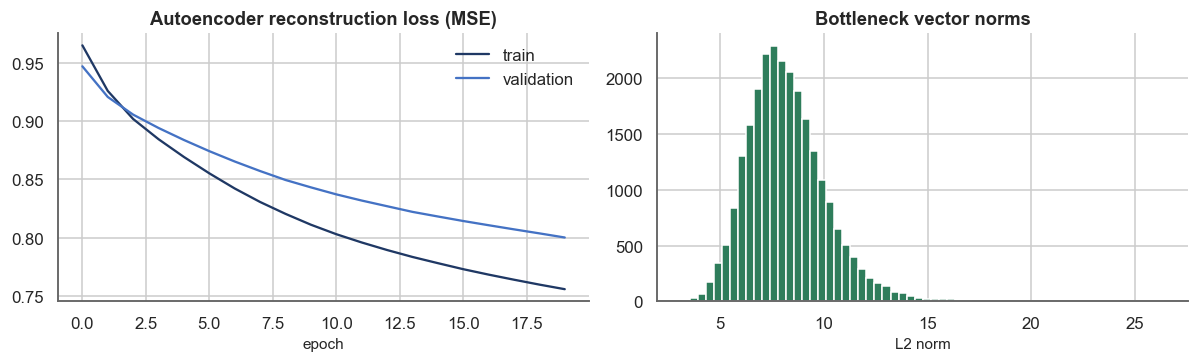

pretrained embeddings: (25000, 128)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(history.history["loss"], color=INK, label="train")
axes[0].plot(history.history["val_loss"], color=ACCENT, label="validation")
axes[0].set_title("Autoencoder reconstruction loss (MSE)")
axes[0].set_xlabel("epoch"); axes[0].legend(frameon=False)

codes = encoder.predict(X_content, batch_size=512, verbose=0)
axes[1].hist(np.linalg.norm(codes, axis=1), bins=60, color=POS)
axes[1].set_title("Bottleneck vector norms"); axes[1].set_xlabel("L2 norm")
sns.despine(); save_fig(fig, "tf_autoencoder_training"); plt.show()
print(f"pretrained embeddings: {codes.shape}")

## 4. Interactions and the temporal split

Identical construction to v0: the same like threshold, the same global timestamp quantile, the
same minimum-history filters. Reusing them is what makes the two models comparable.

In [10]:
inter = (load_table("interactions", lazy=True)
         .filter(pl.col("movie_id").is_in(MOVIE_IDS.tolist()))
         .collect(engine="streaming"))
inter = inter.with_columns(pl.col("rated_at").str.to_datetime())
pop_counts = inter.group_by("movie_id").len()
n_users_total = inter["user_id"].n_unique()
POPULARITY = {int(m): c / n_users_total for m, c in zip(pop_counts["movie_id"], pop_counts["len"])}

cutoff = inter["rated_at"].quantile(TEMPORAL_SPLIT_Q)
likes = inter.filter(pl.col("rating") >= LIKE_THRESHOLD)
train_likes = likes.filter(pl.col("rated_at") < cutoff)
test_likes = likes.filter(pl.col("rated_at") >= cutoff)

train_by_user = train_likes.group_by("user_id").agg(pl.col("movie_id").alias("train_items"))
test_by_user = test_likes.group_by("user_id").agg(pl.col("movie_id").alias("test_items"))
users = (train_by_user.join(test_by_user, on="user_id", how="inner")
         .filter((pl.col("train_items").list.len() >= MIN_TRAIN_LIKES)
                 & (pl.col("test_items").list.len() >= MIN_TEST_LIKES)))
if users.height > N_USERS:
    users = users[np.sort(rng.choice(users.height, size=N_USERS, replace=False))]

USER_TRAIN = [np.asarray(x) for x in users["train_items"].to_list()]
USER_TEST = [set(int(m) for m in x) for x in users["test_items"].to_list()]
print(f"interactions {inter.height:,} | positives {likes.height:,} "
      f"(train {train_likes.height:,}, test {test_likes.height:,})")
print(f"evaluation users: {len(USER_TRAIN):,}")

interactions 9,849,885 | positives 4,842,546 (train 3,879,887, test 962,659)
evaluation users: 2,000


## 5. Stage 2 — two-tower fine-tune

A training example is one `(user, item, rating)` triple drawn from the training window.

**The user's own vector must exclude the target film.** A user is represented by the mean content
of the films they liked, and if the target is inside that mean the model can solve the retrieval
task by reading the answer out of its own input. The mean is therefore recomputed per example as
`(sum - x_target) / (n - 1)`, which is cheap and closes the leak.

The retrieval loss is in-batch sampled softmax: every other item in the batch acts as a negative.
Duplicate items within a batch are masked, otherwise a correct item sitting in another row is
punished as a false negative.

In [11]:
train_pairs = (inter.filter((pl.col("rated_at") < cutoff))
               .select("user_id", "movie_id", "rating"))
if MAX_TRAIN_PAIRS is not None and train_pairs.height > MAX_TRAIN_PAIRS:
    keep = rng.choice(train_pairs.height, size=MAX_TRAIN_PAIRS, replace=False)
    train_pairs = train_pairs[np.sort(keep)]

# Per-user sum of liked-item content, for the leave-one-out profile.
liked_rows = {int(u): np.asarray([ROW_OF[int(m)] for m in items])
              for u, items in zip(train_by_user["user_id"], train_by_user["train_items"])}
user_sum, user_n = {}, {}
for u, rows in liked_rows.items():
    user_sum[u] = X_content[rows].sum(axis=0)
    user_n[u] = len(rows)

pair_u = train_pairs["user_id"].to_numpy()
pair_i = np.array([ROW_OF[int(m)] for m in train_pairs["movie_id"].to_numpy()])
pair_r = train_pairs["rating"].to_numpy().astype(np.float32)

keep = np.array([user_n.get(int(u), 0) >= 2 for u in pair_u])
pair_u, pair_i, pair_r = pair_u[keep], pair_i[keep], pair_r[keep]
print(f"training pairs: {len(pair_u):,} (users with >=2 liked films)")

# Which pairs are positives for the RETRIEVAL head. The rating head still sees
# every pair; only the retrieval target set is restricted.
IS_LIKE = (pair_r >= LIKE_THRESHOLD).astype(np.float32)
print(f"retrieval positives: {int(IS_LIKE.sum()):,} of {len(IS_LIKE):,} "
      f"({IS_LIKE.mean():.1%}) at rating >= {LIKE_THRESHOLD}")

# Compact per-user profile table. The previous version stacked one profile and
# one item vector per PAIR, giving two (n_pairs x feature_dim) float32 arrays:
# at 391,745 pairs and 2,078 features that is 6.5 GB before TensorFlow allocates
# anything, and it runs out of memory. Storing each user once and gathering rows
# inside the tf.data graph makes the cost O(n_users x dim) instead.
PROFILE_USERS = sorted({int(u) for u in pair_u})
_slot = {u: k for k, u in enumerate(PROFILE_USERS)}
USER_SUM_TABLE = np.stack([user_sum[u] for u in PROFILE_USERS]).astype(np.float32)
USER_N_TABLE = np.array([user_n[u] for u in PROFILE_USERS], dtype=np.float32)
USER_IDX = np.array([_slot[int(u)] for u in pair_u], dtype=np.int32)

# Leave-one-out flag: is the target already inside this user's profile sum?
_liked_sets = {u: set(r.tolist()) for u, r in liked_rows.items()}
IN_PROFILE = np.array([pair_i[k] in _liked_sets[int(pair_u[k])] for k in range(len(pair_u))],
                      dtype=np.float32)
print(f"targets removed from their own profile: {int(IN_PROFILE.sum()):,} "
      f"({IN_PROFILE.mean():.1%} of pairs)")

mb = USER_SUM_TABLE.nbytes / 1e6
print(f"profile table {USER_SUM_TABLE.shape} ({mb:,.0f} MB); "
      f"per-pair materialisation would have been "
      f"{2 * len(pair_u) * X_content.shape[1] * 4 / 1e9:,.1f} GB")

training pairs: 391,745 (users with >=2 liked films)
retrieval positives: 194,997 of 391,745 (49.8%) at rating >= 4.0
targets removed from their own profile: 194,997 (49.8% of pairs)
profile table (121216, 1054) (511 MB); per-pair materialisation would have been 3.3 GB


In [12]:
class TwoTowerRecommender(keras.Model):
    """Content-only two-tower model with a joint retrieval and rating objective.

    Neither tower holds a per-user or per-item identity embedding: both consume
    content vectors, so an unseen film or a brand-new user can be embedded.
    """

    def __init__(self, encoder: keras.Model, *, embed_dim=EMBED_DIM, hidden=TOWER_HIDDEN,
                 temperature=TEMPERATURE, retrieval_weight=RETRIEVAL_WEIGHT,
                 rating_weight=RATING_WEIGHT, freeze_encoder=FREEZE_ENCODER,
                 share_trunk=SHARE_TRUNK, like_only=LIKE_ONLY_RETRIEVAL,
                 logq=LOGQ_CORRECTION, **kw):
        super().__init__(**kw)
        self.encoder = encoder
        self.encoder.trainable = not freeze_encoder
        # A user profile is itself a mean of item content vectors, so a single
        # shared trunk lets the model minimise the retrieval loss by mapping
        # everything onto one direction. Measured on this data: shared trunk gave
        # mean pairwise item cosine +0.82 and NDCG@10 0.011; separate towers gave
        # +0.45 and 0.024. Each side therefore gets its own copy of the encoder,
        # both initialised from the autoencoder weights.
        if share_trunk:
            self.user_encoder = encoder
        else:
            self.user_encoder = keras.models.clone_model(encoder)
            self.user_encoder.set_weights(encoder.get_weights())
            self.user_encoder.trainable = not freeze_encoder
        self.temperature = temperature
        self.retrieval_weight = retrieval_weight
        self.rating_weight = rating_weight
        self.like_only = like_only
        self.logq = logq

        def head(name):
            # Input BatchNorm matters here: a user profile is the mean of many item
            # vectors, so its variance is roughly a third of an item's even after the
            # features are standardised. Normalising per side stops the user tower
            # training on a much weaker signal than the item tower.
            seq = [layers.BatchNormalization(name=f"{name}_bn_in")]
            seq += [layers.Dense(w, activation="gelu", name=f"{name}_{i}")
                    for i, w in enumerate(hidden)]
            seq.append(layers.Dense(embed_dim, name=f"{name}_out"))
            return keras.Sequential(seq, name=name)

        self.item_head = head("item_head")
        self.user_head = head("user_head")
        self.rating_head = keras.Sequential(
            [layers.Dense(128, activation="gelu"), layers.Dense(64, activation="gelu"),
             layers.Dense(1)], name="rating_head")
        # A layer, not tf.math.l2_normalize: raw TF ops cannot be applied to the
        # symbolic KerasTensors used when exporting the towers as functional models.
        self.normalize = layers.UnitNormalization(name="l2")

        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.ret_tracker = keras.metrics.Mean(name="retrieval")
        self.rat_tracker = keras.metrics.Mean(name="rmse")
        self.acc_tracker = keras.metrics.Mean(name="top1")

    def embed_items(self, content, training=False):
        return self.normalize(
            self.item_head(self.encoder(content, training=training), training=training))

    def embed_users(self, content, training=False):
        return self.normalize(
            self.user_head(self.user_encoder(content, training=training), training=training))

    def call(self, inputs, training=False):
        u = self.embed_users(inputs["user_content"], training=training)
        i = self.embed_items(inputs["item_content"], training=training)
        rating = self.rating_head(tf.concat([u, i, u * i], axis=-1), training=training)
        return u, i, tf.squeeze(rating, -1)

    def _compute_losses(self, data, training):
        # NB: not named `_losses` - Keras 3 stores its own loss list in
        # `self._losses`, and an instance attribute shadows a method of the
        # same name, so calling it raises "TrackedList is not callable".
        u, i, rating_pred = self(data, training=training)
        logits = tf.matmul(u, i, transpose_b=True) / self.temperature

        if self.logq:
            # Off by default. See the note on LOGQ_CORRECTION in section 0: this
            # collapsed the towers into a popularity chart rather than debiasing
            # them. Kept so the negative result can be reproduced.
            logits = logits - tf.expand_dims(data["item_logp"], 0)

        # Mask duplicate items so an identical film elsewhere in the batch is not
        # counted as a negative for this row.
        ids = data["item_row"]
        same = tf.equal(tf.expand_dims(ids, 1), tf.expand_dims(ids, 0))
        eye = tf.eye(tf.shape(ids)[0], dtype=tf.bool)
        logits = tf.where(same & ~eye, tf.fill(tf.shape(logits), -1e9), logits)

        labels = tf.range(tf.shape(u)[0])
        per_row = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)
        hit = tf.cast(tf.equal(tf.cast(tf.argmax(logits, axis=1), tf.int32), labels), tf.float32)

        if self.like_only:
            # Films the user disliked stay in the batch as negatives; they just
            # stop being targets. The guarded denominator keeps a batch that
            # happens to contain no likes from producing a NaN.
            w = data["is_like"]
            denom = tf.maximum(tf.reduce_sum(w), 1.0)
            retrieval = tf.reduce_sum(per_row * w) / denom
            top1 = tf.reduce_sum(hit * w) / denom
        else:
            retrieval = tf.reduce_mean(per_row)
            top1 = tf.reduce_mean(hit)

        # The rating head still learns from every pair: predicting a low rating
        # is exactly as informative as predicting a high one.
        rating = tf.reduce_mean(tf.square(data["rating"] - rating_pred))
        total = self.retrieval_weight * retrieval + self.rating_weight * rating
        return total, retrieval, rating, top1

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total, retrieval, rating, top1 = self._compute_losses(data, training=True)
        self.optimizer.apply_gradients(
            zip(tape.gradient(total, self.trainable_variables), self.trainable_variables))
        return self._report(total, retrieval, rating, top1)

    def test_step(self, data):
        return self._report(*self._compute_losses(data, training=False))

    def _report(self, total, retrieval, rating, top1):
        # Keras 3 auto-tracks Metric attributes and resets them between epochs,
        # so the `metrics` property must NOT be overridden here: doing so is a
        # Keras 2 pattern and collides with the tracker list Keras 3 maintains.
        self.loss_tracker.update_state(total)
        self.ret_tracker.update_state(retrieval)
        self.rat_tracker.update_state(tf.sqrt(rating))
        self.acc_tracker.update_state(top1)
        return {t.name: t.result() for t in
                (self.loss_tracker, self.ret_tracker, self.rat_tracker, self.acc_tracker)}


model = TwoTowerRecommender(encoder)
print(f"temperature {TEMPERATURE} | retrieval w {RETRIEVAL_WEIGHT} | rating w {RATING_WEIGHT} "
      f"| frozen: {FREEZE_ENCODER} | shared trunk: {SHARE_TRUNK}")
print(f"like-only retrieval: {LIKE_ONLY_RETRIEVAL} | logQ correction: {LOGQ_CORRECTION}")

temperature 0.2 | retrieval w 1.0 | rating w 0.5 | frozen: False | shared trunk: False
like-only retrieval: True | logQ correction: False


In [13]:
def make_dataset(content, user_sum_table, user_n_table,
                 user_idx, item_rows, ratings, is_like, in_profile, item_logp,
                 *, batch, shuffle):
    """Stream training pairs, gathering content inside the graph.

    Only indices are materialised per pair. The catalogue and the profile table
    are each stored once and gathered, which is what keeps the 2048-dimension
    arm of the sweep inside memory.

    The three tables are parameters, not globals. An earlier version closed over
    `X_content`, `USER_SUM_TABLE` and `USER_N_TABLE`; the sweep in section 9
    rebinds only the first, so every width except the current default would have
    gathered a profile of one dimension and an item vector of another and died
    on a shape mismatch inside the tf.data map.
    """
    content_t = tf.constant(content, dtype=tf.float32)
    user_sum_t = tf.constant(user_sum_table, dtype=tf.float32)
    user_n_t = tf.constant(user_n_table, dtype=tf.float32)
    if user_sum_t.shape[1] != content_t.shape[1]:
        msg = (f"profile table is {user_sum_t.shape[1]}-dimensional but the content "
               f"block is {content_t.shape[1]}-dimensional; rebuild the profile "
               f"table from the same block you are gathering items from")
        raise ValueError(msg)

    ds = tf.data.Dataset.from_tensor_slices({
        "user_idx": user_idx.astype(np.int32), "item_row": item_rows.astype(np.int32),
        "rating": ratings.astype(np.float32), "is_like": is_like.astype(np.float32),
        "in_profile": in_profile.astype(np.float32), "item_logp": item_logp.astype(np.float32),
    })
    if shuffle:
        ds = ds.shuffle(min(100_000, len(ratings)), seed=RANDOM_STATE,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch, drop_remainder=True)

    def expand(row):
        item_content = tf.gather(content_t, row["item_row"])
        summed = tf.gather(user_sum_t, row["user_idx"])
        count = tf.gather(user_n_t, row["user_idx"])
        keep = row["in_profile"][:, None]
        profile = (summed - keep * item_content) / tf.maximum(count[:, None] - keep, 1.0)
        return {"user_content": profile, "item_content": item_content,
                "item_row": row["item_row"], "rating": row["rating"],
                "is_like": row["is_like"], "item_logp": row["item_logp"]}

    return ds.map(expand, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


def item_log_probability(rows, n_items):
    """Log sampling probability per pair, from the rows given.

    Must be built from the TRAINING fold alone. Counting over every pair before
    the split lets the validation fold contribute to the frequencies its own
    loss is then corrected by.
    """
    counts = np.bincount(rows, minlength=n_items).astype(np.float64)
    return np.log(np.maximum(counts, 1.0) / counts.sum())[rows].astype(np.float32)


# Shuffle before splitting. The previous version sliced the last 5% positionally
# off a user-ordered frame, so validation was a disjoint set of users rather than
# held-out pairs, and val_top1 was answering a different question from train_top1.
_order = rng.permutation(len(pair_r))
_split = int(0.95 * len(_order))
_tr, _va = _order[:_split], _order[_split:]

ITEM_LOGP = np.zeros(len(pair_r), dtype=np.float32)
ITEM_LOGP[_tr] = item_log_probability(pair_i[_tr], N_ITEMS)
ITEM_LOGP[_va] = item_log_probability(pair_i[_va], N_ITEMS)

train_ds = make_dataset(X_content, USER_SUM_TABLE, USER_N_TABLE,
                        USER_IDX[_tr], pair_i[_tr], pair_r[_tr], IS_LIKE[_tr],
                        IN_PROFILE[_tr], ITEM_LOGP[_tr], batch=TT_BATCH, shuffle=True)
val_ds = make_dataset(X_content, USER_SUM_TABLE, USER_N_TABLE,
                      USER_IDX[_va], pair_i[_va], pair_r[_va], IS_LIKE[_va],
                      IN_PROFILE[_va], ITEM_LOGP[_va], batch=TT_BATCH, shuffle=False)

model.compile(optimizer=keras.optimizers.Adam(TT_LR))
early = keras.callbacks.EarlyStopping(monitor="val_retrieval", mode="min",
                                      patience=EARLY_STOP_PATIENCE,
                                      restore_best_weights=True, verbose=1)
t = time.time()
tt_history = model.fit(train_ds, validation_data=val_ds, epochs=TT_EPOCHS,
                       callbacks=[early], shuffle=False, verbose=2)
print(f"\ntwo-tower trained in {time.time() - t:.0f}s "
      f"({len(tt_history.history['loss'])} of {TT_EPOCHS} epochs)")

# Report the epoch whose weights were actually restored, not the best epoch on a
# metric nobody monitored. EarlyStopping restores on val_retrieval, so the last
# epoch and the best-ever val_top1 both describe a model that is not in memory.
best = int(np.argmin(tt_history.history["val_retrieval"]))
final_top1 = tt_history.history["val_top1"][best]
chance = 1.0 / TT_BATCH
print(f"restored epoch {best + 1} of {len(tt_history.history['loss'])}")
print(f"in-batch top-1 accuracy {final_top1:.4f} against chance {chance:.5f} "
      f"({final_top1 / chance:,.1f}x chance)")
assert final_top1 > 5 * chance, "retrieval head did not learn"

Epoch 1/40
726/726 - 78s - 108ms/step - loss: 6.1342 - retrieval: 5.6183 - rmse: 0.9765 - top1: 0.0210 - val_loss: 5.8783 - val_retrieval: 5.4556 - val_rmse: 0.9191 - val_top1: 0.0282
Epoch 2/40
726/726 - 95s - 130ms/step - loss: 5.8549 - retrieval: 5.4433 - rmse: 0.9067 - top1: 0.0292 - val_loss: 5.8252 - val_retrieval: 5.4113 - val_rmse: 0.9094 - val_top1: 0.0355
Epoch 3/40
726/726 - 206s - 284ms/step - loss: 5.7917 - retrieval: 5.3889 - rmse: 0.8970 - top1: 0.0344 - val_loss: 5.7962 - val_retrieval: 5.3848 - val_rmse: 0.9068 - val_top1: 0.0349
Epoch 4/40
726/726 - 199s - 274ms/step - loss: 5.7464 - retrieval: 5.3495 - rmse: 0.8903 - top1: 0.0376 - val_loss: 5.7797 - val_retrieval: 5.3739 - val_rmse: 0.9005 - val_top1: 0.0373
Epoch 5/40
726/726 - 163s - 225ms/step - loss: 5.7081 - retrieval: 5.3181 - rmse: 0.8826 - top1: 0.0412 - val_loss: 5.7698 - val_retrieval: 5.3614 - val_rmse: 0.9032 - val_top1: 0.0400
Epoch 6/40
726/726 - 158s - 217ms/step - loss: 5.6734 - retrieval: 5.2887 - r

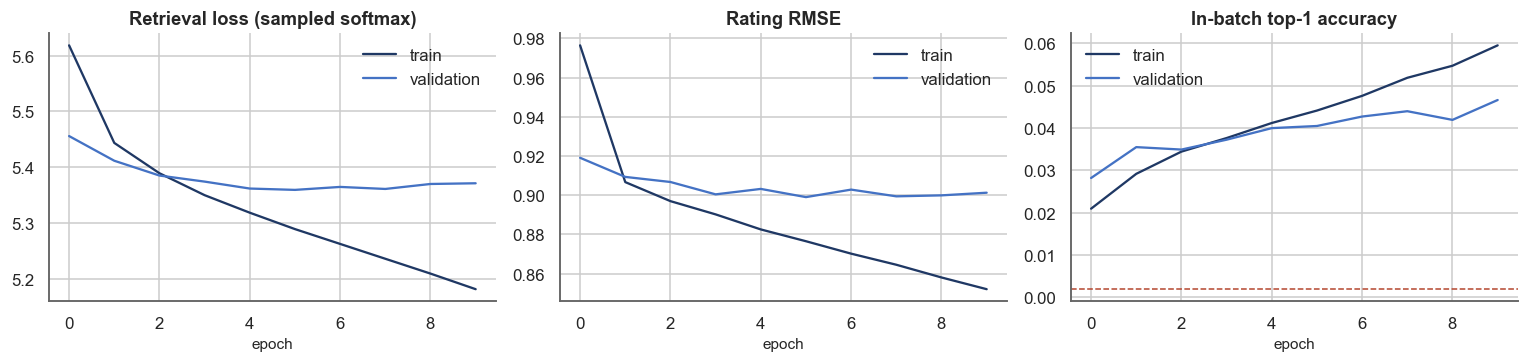

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, key, title in [(axes[0], "retrieval", "Retrieval loss (sampled softmax)"),
                       (axes[1], "rmse", "Rating RMSE"),
                       (axes[2], "top1", "In-batch top-1 accuracy")]:
    ax.plot(tt_history.history[key], color=INK, label="train")
    ax.plot(tt_history.history[f"val_{key}"], color=ACCENT, label="validation")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(frameon=False)
axes[2].axhline(chance, color=NEG, ls="--", lw=1, label="chance")
sns.despine(); save_fig(fig, "tf_twotower_training"); plt.show()

## 6. Item embeddings and retrieval

In [15]:
ITEM_EMB = model.embed_items(X_content, training=False).numpy().astype(np.float32)
print(f"item embeddings {ITEM_EMB.shape} | rows unit-norm: "
      f"{np.allclose(np.linalg.norm(ITEM_EMB, axis=1), 1.0, atol=1e-4)}")


def similar_v1(movie_id: int, k: int = K_PRIMARY) -> np.ndarray:
    row = ROW_OF[int(movie_id)]
    scores = ITEM_EMB @ ITEM_EMB[row]
    scores[row] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    return MOVIE_IDS[top[np.argsort(-scores[top])]]


def user_topk_v1(profiles: np.ndarray, k: int, seen=None, block: int = 256) -> np.ndarray:
    """Embed a batch of user content profiles and retrieve their top-k items."""
    out = np.empty((len(profiles), k), dtype=np.int32)
    for s in range(0, len(profiles), block):
        emb = model.embed_users(profiles[s:s + block], training=False).numpy()
        scores = emb @ ITEM_EMB.T
        if seen is not None:
            for j, already in enumerate(seen[s:s + block]):
                rows = [ROW_OF[int(m)] for m in already if int(m) in ROW_OF]
                if rows:
                    scores[j, rows] = -np.inf
        for j in range(scores.shape[0]):
            top = np.argpartition(-scores[j], k)[:k]
            out[s + j] = MOVIE_IDS[top[np.argsort(-scores[j][top])]]
    return out


for probe in ("Toy Story", "The Godfather"):
    hits = [i for i, t in enumerate(TITLES) if t.strip().casefold() == probe.casefold()]
    if not hits:
        print(f"\n{probe!r} not in the sampled catalogue"); continue
    mid = int(MOVIE_IDS[hits[0]])
    print(f"\n{probe}  ->  " + " | ".join(TITLES[ROW_OF[int(m)]] for m in similar_v1(mid, 6)))

item embeddings (25000, 128) | rows unit-norm: True

Toy Story  ->  Sense and Sensibility | Muppet Treasure Island | Ransom | Beauty and the Beast | Phenomenon | Matilda

'The Godfather' not in the sampled catalogue


mean pairwise item cosine +0.355 (p05 -0.151, p95 +0.770)


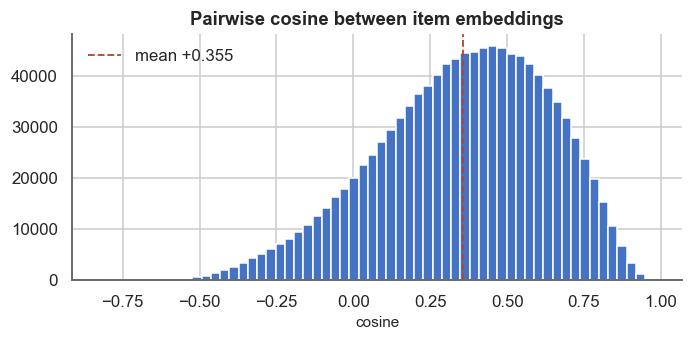

In [16]:
# Collapse check. If every film points the same way, retrieval is meaningless no
# matter what the loss curve says. This is the diagnostic that explained the first
# failed configuration, so it stays in the notebook permanently.
probe = rng.choice(N_ITEMS, size=min(1500, N_ITEMS), replace=False)
sample = ITEM_EMB[probe]
pair_cos = (sample @ sample.T)[np.triu_indices(len(probe), 1)]
print(f"mean pairwise item cosine {pair_cos.mean():+.3f} "
      f"(p05 {np.percentile(pair_cos, 5):+.3f}, p95 {np.percentile(pair_cos, 95):+.3f})")
if pair_cos.mean() > 0.6:
    print("WARNING: embeddings have collapsed toward a single direction.")
    print("Raise TEMPERATURE, set SHARE_TRUNK=False, or train longer.")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(pair_cos, bins=60, color=ACCENT)
ax.axvline(pair_cos.mean(), color=NEG, ls="--", lw=1.2, label=f"mean {pair_cos.mean():+.3f}")
ax.set_title("Pairwise cosine between item embeddings")
ax.set_xlabel("cosine"); ax.legend(frameon=False)
sns.despine(); save_fig(fig, "tf_embedding_spread"); plt.show()

## 7. Evaluation

The v0 baseline is **recomputed here** on the same catalogue, the same users and the same split.
Quoting numbers across notebooks would leave open the possibility that a difference in sampling,
not in modelling, explains the gap.

In [17]:
def precision_at_k(rec, rel, k):
    return sum(1 for m in rec[:k] if m in rel) / k


def recall_at_k(rec, rel, k):
    return np.nan if not rel else sum(1 for m in rec[:k] if m in rel) / len(rel)


def ndcg_at_k(rec, rel, k):
    if not rel:
        return np.nan
    gains = np.array([1.0 if m in rel else 0.0 for m in rec[:k]])
    disc = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    ideal = disc[:min(len(rel), k)].sum()
    return float((gains * disc).sum()) / ideal if ideal > 0 else np.nan


def intra_list_diversity(rec, k):
    rows = [ROW_OF[int(m)] for m in rec[:k] if int(m) in ROW_OF]
    if len(rows) < 2:
        return np.nan
    tot = pairs = 0
    for a in range(len(rows)):
        ga = GENRE_SETS[rows[a]]
        for b in range(a + 1, len(rows)):
            gb = GENRE_SETS[rows[b]]
            union = ga | gb
            tot += 1.0 - (len(ga & gb) / len(union) if union else 0.0)
            pairs += 1
    return tot / pairs if pairs else np.nan


def novelty(rec, k):
    return float(np.mean([-np.log2(max(POPULARITY.get(int(m), 1e-9), 1e-9)) for m in rec[:k]]))


def catalogue_coverage(lists, k):
    return len({int(m) for row in lists for m in row[:k]}) / N_ITEMS


def score_lists(lists, truths, label):
    out = {"model": label}
    for k in K_VALUES:
        out[f"P@{k}"] = float(np.mean([precision_at_k(r, t, k) for r, t in zip(lists, truths)]))
        out[f"R@{k}"] = float(np.nanmean([recall_at_k(r, t, k) for r, t in zip(lists, truths)]))
        out[f"NDCG@{k}"] = float(np.nanmean([ndcg_at_k(r, t, k) for r, t in zip(lists, truths)]))
    out["ILD"] = float(np.nanmean([intra_list_diversity(r, K_PRIMARY) for r in lists]))
    out["Novelty"] = float(np.nanmean([novelty(r, K_PRIMARY) for r in lists]))
    out["CatCov"] = catalogue_coverage(lists, K_PRIMARY)
    return out

In [18]:
# --- v0 baseline, recomputed on this exact catalogue and user sample ---
X_v0 = X_tfidf                                   # same vectoriser, same films
seen = [set(int(m) for m in items) for items in USER_TRAIN]

rows, cols, vals = [], [], []
for u, items in enumerate(USER_TRAIN):
    idx = [ROW_OF[int(m)] for m in items if int(m) in ROW_OF]
    rows.extend([u] * len(idx)); cols.extend(idx); vals.extend([1.0 / len(idx)] * len(idx))
selector = sp.csr_matrix((np.asarray(vals, dtype=np.float32), (rows, cols)),
                         shape=(len(USER_TRAIN), N_ITEMS), dtype=np.float32)
prof_v0 = normalize(selector @ X_v0)

lists_v0 = np.empty((len(USER_TRAIN), max(K_VALUES)), dtype=np.int32)
for s in range(0, prof_v0.shape[0], 256):
    chunk = prof_v0[s:s + 256]
    sc = safe_sparse_dot(chunk, X_v0.T)
    sc = sc.toarray() if sp.issparse(sc) else np.asarray(sc)
    for j, already in enumerate(seen[s:s + 256]):
        r = [ROW_OF[int(m)] for m in already if int(m) in ROW_OF]
        if r:
            sc[j, r] = -np.inf
    for j in range(sc.shape[0]):
        top = np.argpartition(-sc[j], max(K_VALUES))[:max(K_VALUES)]
        lists_v0[s + j] = MOVIE_IDS[top[np.argsort(-sc[j][top])]]

# --- v1 ---
prof_v1 = np.stack([X_content[[ROW_OF[int(m)] for m in items if int(m) in ROW_OF]].mean(axis=0)
                    for items in USER_TRAIN]).astype(np.float32)
lists_v1 = user_topk_v1(prof_v1, max(K_VALUES), seen=seen)

# Popularity floor. Recommending the most-rated films to everyone uses no content
# and no personalisation, so any model at or below this line is ranking by
# popularity whatever its NDCG says. This guard is not decoration: while tuning
# v1 on a synthetic log, a variant scored ten times the control and turned out to
# have collapsed onto 22 films, landing exactly on this baseline. Without the
# floor it read as the best result in the table.
pop_rank = sorted(range(N_ITEMS), key=lambda r: -POPULARITY.get(int(MOVIE_IDS[r]), 0.0))
lists_pop = np.empty((len(USER_TRAIN), max(K_VALUES)), dtype=np.int32)
for j, already in enumerate(seen):
    picks = [int(MOVIE_IDS[r]) for r in pop_rank if int(MOVIE_IDS[r]) not in already]
    lists_pop[j] = picks[:max(K_VALUES)]

comparison = pd.DataFrame([
    score_lists(lists_v0, USER_TEST, "v0 combined / TF-IDF cosine"),
    score_lists(lists_v1, USER_TEST, "v1 TensorFlow two-tower"),
    score_lists(lists_pop, USER_TEST, "popularity floor (no content)"),
])
display(comparison.round(4))

d0, d1, dp = (comparison.loc[k, f"NDCG@{K_PRIMARY}"] for k in (0, 1, 2))
print(f"NDCG@{K_PRIMARY}: v0 {d0:.4f} | v1 {d1:.4f} | popularity {dp:.4f}")
print(f"v1 against v0: {'+' if d1 >= d0 else ''}{(d1 - d0) / max(d0, 1e-9):.1%}")
if d1 <= dp * 1.02 and comparison.loc[1, "CatCov"] < 0.02:
    print("WARNING: v1 is at the popularity floor with near-zero catalogue coverage. "
          "That is a collapsed model scoring well on a popularity-dominated test set, "
          "not a working recommender. Check mean pairwise item cosine and val_top1.")

,model,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20,ILD,Novelty,CatCov
0,v0 combined / TF-IDF cosine,0.0357,0.0147,0.0390,0.0319,0.0271,0.0393,0.0266,0.0450,0.0422,0.6274,8.9157,0.0522
1,v1 TensorFlow two-tower,0.0412,0.0228,0.0477,0.0341,0.0353,0.0462,0.0277,0.0559,0.0491,0.7177,10.3676,0.1508
2,popularity floor (no content),0.0532,0.0224,0.0594,0.0428,0.0337,0.0557,0.0419,0.0658,0.0637,0.8527,2.3691,0.0021


NDCG@10: v0 0.0393 | v1 0.0462 | popularity 0.0557
v1 against v0: +17.4%


In [19]:
# Rating head: RMSE and MAE on held-out interactions from the test window.
# Only users with a training profile can be scored: the rating head needs a user
# vector, and that vector is built from films they liked before the cut-off.
profiled = pl.Series("u", list(user_n.keys()), dtype=pl.Int32)
test_pairs = (inter.filter(pl.col("rated_at") >= cutoff)
              .select("user_id", "movie_id", "rating")
              .filter(pl.col("user_id").is_in(profiled)))
tu = test_pairs["user_id"].to_numpy()
ti = np.array([ROW_OF[int(m)] for m in test_pairs["movie_id"].to_numpy()])
tr = test_pairs["rating"].to_numpy().astype(np.float32)
if len(tr) > 200_000:
    pick = rng.choice(len(tr), 200_000, replace=False)
    tu, ti, tr = tu[pick], ti[pick], tr[pick]

tu_x = np.stack([user_sum[int(u)] / user_n[int(u)] for u in tu]).astype(np.float32)
preds = []
for s in range(0, len(tr), 4096):
    _, _, p = model({"user_content": tu_x[s:s + 4096],
                     "item_content": X_content[ti[s:s + 4096]]}, training=False)
    preds.append(p.numpy())
preds = np.concatenate(preds)

rmse = float(np.sqrt(np.mean((tr - preds) ** 2)))
mae = float(np.mean(np.abs(tr - preds)))
base_rmse = float(np.sqrt(np.mean((tr - tr.mean()) ** 2)))
print(f"held-out interactions scored: {len(tr):,}")
print(f"  RMSE {rmse:.4f}   (predict-the-mean baseline {base_rmse:.4f})")
print(f"  MAE  {mae:.4f}")

held-out interactions scored: 200,000
  RMSE 0.9227   (predict-the-mean baseline 0.9971)
  MAE  0.7079


In [20]:
# Cold start: films with almost no ratings, scored by genre overlap because no
# behavioural ground truth exists for them.
rating_counts = catalogue["ml_rating_count"].fill_null(0).to_numpy()
cold_rows = np.where(rating_counts < COLD_VOTE_THRESHOLD)[0]
cold_seeds = rng.choice(cold_rows, size=min(300, len(cold_rows)), replace=False)
MIN_SHARED = 2


def genre_truth(row, limit=400):
    target = GENRE_SETS[row]
    if len(target) < MIN_SHARED:
        return set()
    return {int(MOVIE_IDS[i]) for i, s in enumerate(GENRE_SETS)
            if i != row and len(target & s) >= MIN_SHARED}


def cold_eval(fn, label):
    lists, truths = [], []
    for row in cold_seeds:
        rel = genre_truth(int(row))
        if rel:
            lists.append(fn(int(MOVIE_IDS[row]), max(K_VALUES))); truths.append(rel)
    res = score_lists(np.vstack(lists), truths, label)
    res["seeds"] = len(truths)
    return res


def similar_v0(movie_id, k):
    row = ROW_OF[int(movie_id)]
    sc = safe_sparse_dot(X_v0, X_v0[row].T)
    sc = (sc.toarray() if sp.issparse(sc) else np.asarray(sc)).ravel()
    sc[row] = -np.inf
    top = np.argpartition(-sc, k)[:k]
    return MOVIE_IDS[top[np.argsort(-sc[top])]]


cold = pd.DataFrame([cold_eval(similar_v0, "v0 cold-start"),
                     cold_eval(similar_v1, "v1 cold-start")])
display(cold.round(4))
print(f"\ncold films: {len(cold_rows):,} of {N_ITEMS:,} ({len(cold_rows)/N_ITEMS:.1%})")
print("Neither tower holds an identity embedding, so v1 can rank these from content alone.")

,model,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20,ILD,Novelty,CatCov,seeds
0,v0 cold-start,0.3173,0.0022,0.3189,0.3086,0.0052,0.3126,0.3006,0.0107,0.3052,0.7391,16.8320,0.0610,162
1,v1 cold-start,0.1765,0.0008,0.1790,0.1710,0.0016,0.1743,0.1596,0.0028,0.1652,0.7421,16.9972,0.0614,162



cold films: 15,840 of 25,000 (63.4%)
Neither tower holds an identity embedding, so v1 can rank these from content alone.


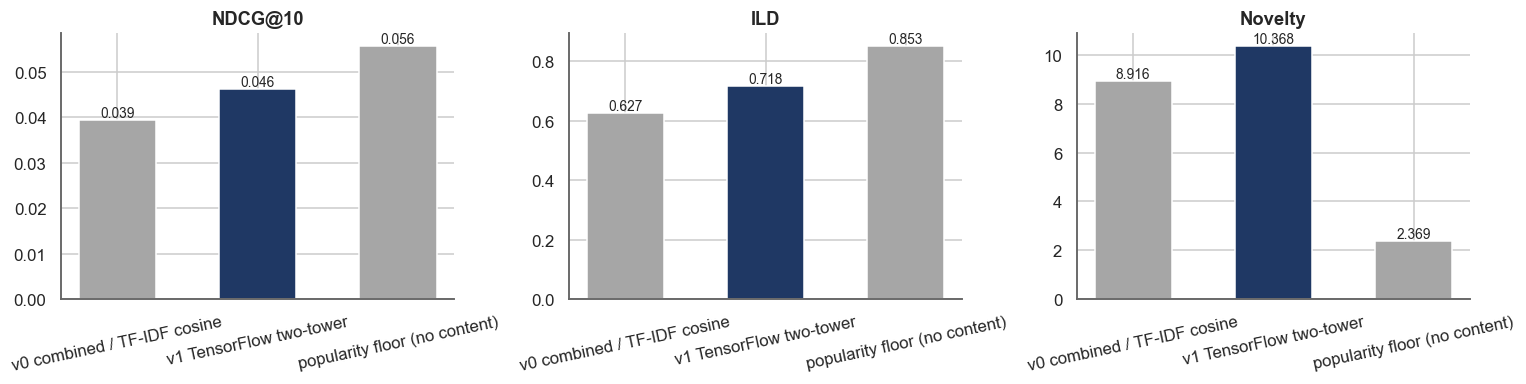

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, metric in zip(axes, [f"NDCG@{K_PRIMARY}", "ILD", "Novelty"]):
    ax.bar(comparison["model"], comparison[metric], color=[MUTED, INK], width=.55)
    ax.set_title(metric); ax.tick_params(axis="x", rotation=12)
    for j, v in enumerate(comparison[metric]):
        ax.text(j, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
sns.despine(); save_fig(fig, "tf_v0_vs_v1"); plt.show()

## 8. Saving the model

In [22]:
import joblib

# A subclassed Model needs get_config() to serialise, because `encoder` is a
# non-serialisable __init__ argument. Rather than write that boilerplate, export
# the two inference paths as *functional* models: they load with plain
# keras.saving.load_model and need no class from this notebook, which is the same
# portability rule the v0 joblib bundle follows.
_content_in = keras.Input(shape=(FEATURE_DIM,), name="content")
item_tower = keras.Model(_content_in, model.embed_items(_content_in), name="item_tower")
user_tower = keras.Model(_content_in, model.embed_users(_content_in), name="user_tower")
item_tower.save(MODEL_ARTIFACTS / "item_tower.keras")
user_tower.save(MODEL_ARTIFACTS / "user_tower.keras")

# Full trainable state, for resuming or for the ablations. Reloading these does
# need the TwoTowerRecommender class.
model.save_weights(MODEL_ARTIFACTS / "two_tower.weights.h5")
encoder.save(MODEL_ARTIFACTS / "content_encoder.keras")
np.savez_compressed(MODEL_ARTIFACTS / "item_embeddings.npz",
                    embeddings=ITEM_EMB, movie_id=MOVIE_IDS.astype(np.int32))

# Everything needed to featurise an unseen film, as plain data so it unpickles
# without any class from this notebook.
joblib.dump({
    "tfidf": tfidf, "svd": svd, "scaler": scaler,
    "keep_genres": KEEP_GENRES, "numeric": NUMERIC, "logged": sorted(LOGGED),
    "feature_dim": FEATURE_DIM, "embed_dim": EMBED_DIM,
    "movie_ids": MOVIE_IDS.astype(np.int32),
}, MODEL_ARTIFACTS / "feature_pipeline.joblib", compress=0, protocol=5)

comparison.to_csv(MODEL_ARTIFACTS / "v0_vs_v1.csv", index=False)
cold.to_csv(MODEL_ARTIFACTS / "cold_start.csv", index=False)
(MODEL_ARTIFACTS / "manifest.json").write_text(json.dumps({
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "tensorflow": tf.__version__, "keras": keras.__version__,
    "config": {"MAX_ITEMS": MAX_ITEMS, "EMBED_DIM": EMBED_DIM, "TEXT_SVD_DIMS": TEXT_SVD_DIMS,
               "AE_EPOCHS": AE_EPOCHS, "TT_EPOCHS": TT_EPOCHS, "TT_BATCH": TT_BATCH,
               "TEMPERATURE": TEMPERATURE, "RETRIEVAL_WEIGHT": RETRIEVAL_WEIGHT,
               "RATING_WEIGHT": RATING_WEIGHT, "MAX_TRAIN_PAIRS": MAX_TRAIN_PAIRS,
               "FREEZE_ENCODER": FREEZE_ENCODER},
    "autoencoder_val_r2": r2,
    "twotower_val_top1": float(final_top1),
    "rating_rmse": rmse, "rating_mae": mae, "mean_baseline_rmse": base_rmse,
    "ndcg10_v0": float(d0), "ndcg10_v1": float(d1),
}, indent=2, default=str))

print(f"saved to {MODEL_ARTIFACTS.relative_to(ROOT)}")
display(pd.DataFrame([{"file": p.name, "MB": round(p.stat().st_size / 1024**2, 2)}
                      for p in sorted(MODEL_ARTIFACTS.iterdir())]))

saved to models\tf_v1


,file,MB
0,cold_start.csv,0.00
1,content_encoder.keras,2.74
2,feature_pipeline.joblib,213.48
3,item_embeddings.npz,11.37
4,item_tower.keras,3.01
5,manifest.json,0.00
6,two_tower.weights.h5,18.47
7,user_tower.keras,3.01
8,v0_vs_v1.csv,0.00


In [23]:
# Cold-start proof: featurise a film that never existed and embed it. Nothing is
# retrained, and no identity lookup is involved.
def featurise(overview: str, genres: list[str], *, runtime=110.0, year=2026.0) -> np.ndarray:
    text = svd.transform(tfidf.transform([overview.lower()])).astype(np.float32)
    genre_vec = np.array([[1.0 if g in genres else 0.0 for g in KEEP_GENRES]], dtype=np.float32)
    raw = pd.DataFrame([{**{c: np.nan for c in NUMERIC},
                         "release_year": year, "runtime_minutes": runtime}])[NUMERIC]
    flags = raw[["budget", "revenue", "runtime_minutes"]].isna().astype(np.float32).to_numpy()
    for c in LOGGED:
        raw[c] = np.log1p(raw[c])
    raw = raw.fillna(pd.Series(scaler.mean_, index=NUMERIC))
    nums = np.hstack([scaler.transform(raw).astype(np.float32), flags])
    return np.hstack([text, genre_vec, nums]).astype(np.float32)


unseen = featurise(
    "A retired thief is pulled back for one last heist in Tokyo, betrayed by the crew he trained.",
    ["Action", "Thriller", "Crime"])
emb = model.embed_items(unseen, training=False).numpy()
scores = (ITEM_EMB @ emb[0])
top = np.argsort(-scores)[:8]
print("unseen film -> nearest catalogue films:")
for i in top:
    print(f"   {scores[i]:.3f}  {TITLES[i]}")

unseen film -> nearest catalogue films:
   0.974  Life with Murder
   0.972  Officer Downe
   0.963  The Dead Lands
   0.960  Spring Breakdown
   0.959  Cash For Trash
   0.959  The Undocumented Lawyer
   0.959  Sivappu Manjal Pachai
   0.959  Ditched


## 9. What the text bottleneck costs

In [24]:
# Section 9 - how much does the text bottleneck cost?
#
# v1 compresses a 54,135-dimension TF-IDF matrix into TEXT_SVD_DIMS dense
# dimensions before the towers ever see it, while v0 reads that matrix at full
# rank. The explained variance retained is 0.123 at 256 dims and only 0.410 at
# 2048, so the two models are not reading the same information, and the gap
# between them is partly a rank gap rather than an architecture gap. This cell
# quantifies it by rebuilding the text block at each width and retraining.
#
# Expect roughly len(SWEEP_DIMS) times a single training run.
if RUN_SWEEP:
    sweep_rows = []
    for dims in SWEEP_DIMS:
        t0 = time.time()
        # Keras keeps global layer-name and graph-trace caches, so four models
        # built in one process accumulate memory the gather rewrite does not
        # address. Without this the last and largest width is the one that dies.
        keras.backend.clear_session()
        gc.collect()

        svd_d = TruncatedSVD(n_components=dims, random_state=RANDOM_STATE)
        text_d = StandardScaler().fit_transform(svd_d.fit_transform(X_tfidf)).astype(np.float32)
        content_d = np.hstack([text_d, X_genre, X_num]).astype(np.float32)

        # The profile table is derived from the content block, so it has to be
        # rebuilt at every width. Reusing the one from section 5 would gather a
        # profile of one dimension against an item vector of another and die on
        # a shape mismatch inside the tf.data map.
        user_sum_d = np.stack([content_d[liked_rows[u]].sum(axis=0)
                               for u in PROFILE_USERS]).astype(np.float32)

        keras.utils.set_random_seed(RANDOM_STATE)
        enc_d = build_encoder(content_d.shape[1])
        dec_d = build_decoder(content_d.shape[1])
        ae_d = keras.Model(enc_d.input, dec_d(enc_d.output))
        ae_d.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
        ae_d.fit(content_d, content_d, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

        tr_d = make_dataset(content_d, user_sum_d, USER_N_TABLE,
                            USER_IDX[_tr], pair_i[_tr], pair_r[_tr], IS_LIKE[_tr],
                            IN_PROFILE[_tr], ITEM_LOGP[_tr], batch=TT_BATCH, shuffle=True)
        va_d = make_dataset(content_d, user_sum_d, USER_N_TABLE,
                            USER_IDX[_va], pair_i[_va], pair_r[_va], IS_LIKE[_va],
                            IN_PROFILE[_va], ITEM_LOGP[_va], batch=TT_BATCH, shuffle=False)

        m_d = TwoTowerRecommender(enc_d)
        m_d.compile(optimizer=keras.optimizers.Adam(TT_LR))
        h_d = m_d.fit(tr_d, validation_data=va_d, epochs=TT_EPOCHS, shuffle=False, verbose=0,
                      callbacks=[keras.callbacks.EarlyStopping(
                          monitor="val_retrieval", mode="min",
                          patience=EARLY_STOP_PATIENCE, restore_best_weights=True)])

        emb_d = m_d.embed_items(content_d, training=False).numpy().astype(np.float32)
        prof_d = np.stack([content_d[[ROW_OF[int(m)] for m in items if int(m) in ROW_OF]]
                           .mean(axis=0) for items in USER_TRAIN]).astype(np.float32)
        lists_d = np.empty((len(prof_d), max(K_VALUES)), dtype=np.int32)
        for start in range(0, len(prof_d), 256):
            e = m_d.embed_users(prof_d[start:start + 256], training=False).numpy()
            sc = e @ emb_d.T
            for j, already in enumerate(seen[start:start + 256]):
                r = [ROW_OF[int(m)] for m in already if int(m) in ROW_OF]
                if r:
                    sc[j, r] = -np.inf
            for j in range(sc.shape[0]):
                top = np.argpartition(-sc[j], max(K_VALUES))[:max(K_VALUES)]
                lists_d[start + j] = MOVIE_IDS[top[np.argsort(-sc[j][top])]]

        probe_d = rng.choice(N_ITEMS, size=min(1500, N_ITEMS), replace=False)
        sm = emb_d[probe_d]
        cos_d = (sm @ sm.T)[np.triu_indices(len(probe_d), 1)]
        # EarlyStopping restored on val_retrieval, so read val_top1 at that
        # epoch. The last epoch and the best-ever val_top1 both describe a model
        # that is no longer in memory.
        best_d = int(np.argmin(h_d.history["val_retrieval"]))

        row = score_lists(lists_d, USER_TEST, f"svd {dims}")
        row.update({"svd_dims": dims,
                    "explained_var": round(float(svd_d.explained_variance_ratio_.sum()), 3),
                    "pair_cos": round(float(cos_d.mean()), 3),
                    "val_top1": round(float(h_d.history["val_top1"][best_d]), 4),
                    "epochs": len(h_d.history["loss"]),
                    "secs": int(time.time() - t0)})
        sweep_rows.append(row)
        print(f"svd {dims:>5} | EV {row['explained_var']:.3f} | "
              f"NDCG@{K_PRIMARY} {row[f'NDCG@{K_PRIMARY}']:.4f} | "
              f"pairCos {row['pair_cos']:+.3f} | {row['secs']}s")

        for name in ("enc_d", "dec_d", "ae_d", "m_d", "tr_d", "va_d",
                     "content_d", "user_sum_d", "emb_d", "prof_d"):
            globals().pop(name, None)

    sweep = pd.DataFrame(sweep_rows)[
        ["svd_dims", "explained_var", f"NDCG@{K_PRIMARY}", "pair_cos",
         "val_top1", "ILD", "Novelty", "CatCov", "epochs", "secs"]]
    display(sweep.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].plot(sweep["explained_var"], sweep[f"NDCG@{K_PRIMARY}"], "o-", color=ACCENT)
    for _, r in sweep.iterrows():
        axes[0].annotate(f"{int(r['svd_dims'])}",
                         (r["explained_var"], r[f"NDCG@{K_PRIMARY}"]),
                         textcoords="offset points", xytext=(5, -9), fontsize=9)
    axes[0].axhline(d0, color=NEG, ls="--", lw=1.2, label=f"v0 {d0:.4f}")
    axes[0].axhline(dp, color=MUTED, ls=":", lw=1.2, label=f"popularity {dp:.4f}")
    axes[0].set_xlabel("TF-IDF variance retained")
    axes[0].set_ylabel(f"NDCG@{K_PRIMARY}")
    axes[0].set_title("Ranking accuracy against text rank")
    axes[0].legend()
    axes[1].plot(sweep["svd_dims"], sweep["pair_cos"], "o-", color=INK)
    axes[1].set_xscale("log", base=2)
    axes[1].set_xlabel("SVD dimensions")
    axes[1].set_ylabel("mean pairwise item cosine")
    axes[1].set_title("Embedding concentration")
    save_fig(fig, "tf_v1_svd_sweep")
    plt.show()
else:
    print("RUN_SWEEP is False. Set it in section 0 to rebuild the text block at "
          f"{SWEEP_DIMS} and retrain at each width.")

RUN_SWEEP is False. Set it in section 0 to rebuild the text block at (256, 512, 1024, 2048) and retrain at each width.


---
## 9. Notes

**What v1 changes.** v0 fixes the geometry: cosine over TF-IDF, with no parameters. v1 keeps
content as the sole item input but learns the mapping into embedding space from 33.8M
interactions. Films that share vocabulary but are never co-liked can be pushed apart, which a
fixed cosine cannot do.

**Cold start.** No identity embeddings anywhere. The final cell embeds a film that does not
exist, using only its synopsis and genres — that is the capability the whole project argues for,
and it is why the reference notebook's ID-lookup towers were not reused.

**Ablations already wired.** `FREEZE_ENCODER=True` isolates the value of fine-tuning against
frozen autoencoder features. `RATING_WEIGHT=0` gives retrieval-only. `TEXT_SVD_DIMS` and
`EMBED_DIM` trade capacity against overfitting.

**Reading the numbers.** Absolute values depend on `MAX_ITEMS` exactly as in v0. The v0 row in
the comparison table is recomputed here rather than quoted, so the two rows differ only in the
model.

**Honest limits.** A content model cannot approach perfect ranking accuracy against held-out
behaviour: what people watch is driven by mood, availability and recency, none of which appear in
the features. The target is beating v0 while keeping cold start, not saturating the metric. If
this ever reports near-perfect accuracy, suspect leakage first — the most likely culprit being a
user profile that contains its own target, which section 5 removes explicitly.